In [1]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wholesale_customers = fetch_ucirepo(id=292)

# data (as pandas dataframes)
X = wholesale_customers.data.features
y = wholesale_customers.data.targets

In [2]:
import pandas as pd
import numpy as np



In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

Data Preparation

In [4]:
print(f"Original data shape: {X.shape}")
print(f"\nFirst 5 rows:\n{X.head()}")
print(f"\nData Info:")
print(X.info())
print(f"\nDescriptive Statistics:")
print(X.describe())

Original data shape: (440, 7)

First 5 rows:
   Channel  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2  12669  9656     7561     214              2674        1338
1        2   7057  9810     9568    1762              3293        1776
2        2   6353  8808     7684    2405              3516        7844
3        1  13265  1196     4221    6404               507        1788
4        2  22615  5410     7198    3915              1777        5185

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Fresh             440 non-null    int64
 2   Milk              440 non-null    int64
 3   Grocery           440 non-null    int64
 4   Frozen            440 non-null    int64
 5   Detergents_Paper  440 non-null    int64
 6   Delicassen        440 non-null    int64
dtypes: 

In [5]:
print(f"\nChannel distribution:\n{X['Channel'].value_counts()}")
print( "(1 = Horeca/Resturant/Cafe, 2 = Retail)")


Channel distribution:
Channel
1    298
2    142
Name: count, dtype: int64
(1 = Horeca/Resturant/Cafe, 2 = Retail)


In [6]:
identifiers = X[['Channel']].copy()
features = X.drop('Channel', axis = 1).copy()

print(f"\nFeatures for clustering ({features.shape[1]} categories):")
print(f" {list(features.columns)}")
print(f"\nMissing values: {features.isnull().sum().sum}")


Features for clustering (6 categories):
 ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

Missing values: <bound method Series.sum of Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64>


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings ('ignore')

In [8]:

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features_scaled_df = pd.DataFrame(features_scaled, columns=features.columns)

print(f"\nScaled data shape: {features_scaled.shape}")
print(f"Scaling check - Mean: {np.abs(features_scaled.mean(axis=0)).max():.6f} (should be ~0)")
print(f"Scaling check - Std: {features_scaled.std(axis=0).mean():.3f} (should be ~1)")


Scaled data shape: (440, 6)
Scaling check - Mean: 0.000000 (should be ~0)
Scaling check - Std: 1.000 (should be ~1)


In [9]:
print(f"\n" + "="*60)
print("Data Preparation Done")
print("="*60)
print(f"- Total records: {features.shape[0]}")
print(f"- Features: {features.shape[1]} (Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen)")
print(f"- Identifier: Channel (1=Horeca, 2=Retail)")
print(f"- Preprocessing: StandardScaler applied, no missing values")


Data Preparation Done
- Total records: 440
- Features: 6 (Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen)
- Identifier: Channel (1=Horeca, 2=Retail)
- Preprocessing: StandardScaler applied, no missing values


Dimensionality Reduction (PCA)

In [10]:
pca_full = PCA()
pca_full.fit(features_scaled)

explained_var = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print(f"\nExplained variance by component:")
for i, var in enumerate(explained_var):
    marker = " <--"if i < 4 else ""
    print(f" PC{i+1}: {var:.3f} ({var*100:.1f}%){marker}")


Explained variance by component:
 PC1: 0.441 (44.1%) <--
 PC2: 0.284 (28.4%) <--
 PC3: 0.123 (12.3%) <--
 PC4: 0.094 (9.4%) <--
 PC5: 0.048 (4.8%)
 PC6: 0.010 (1.0%)


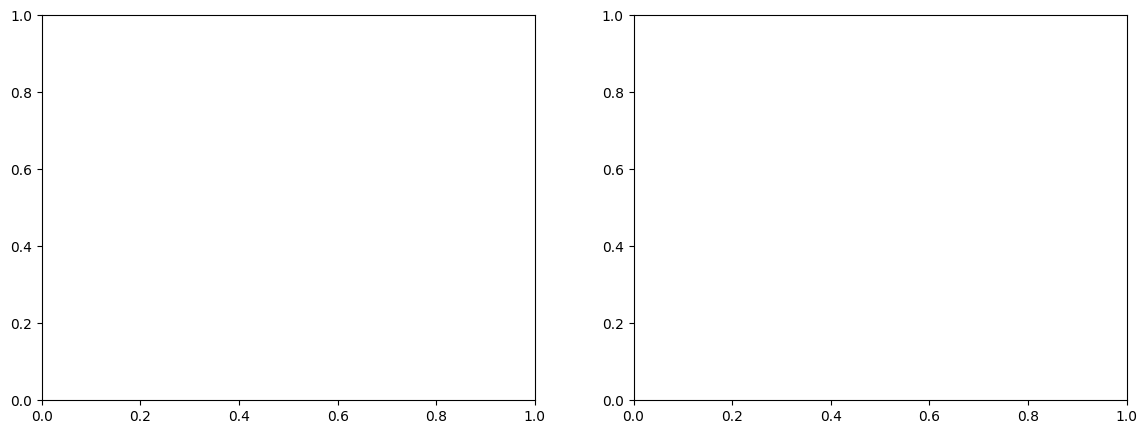

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [12]:
axes[0].plot(range(1, len(explained_var) +1), explained_var, 'bo-', markersize=8, linewidth=2)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('Scree Plot: Individual Explained Variance', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(1, len(explained_var) + 1))

axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var, 'ro-', markersize=8, linewidth=2)
axes[1].axhline(y=0.8, color='orange', linestyle='--', alpha=0.7, label='80% Variance')
axes[1].axhline(y=0.9, color='green', linestyle='--', alpha=0.7, label='90% Variance')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[1].set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(1, len(cumulative_var) + 1))


In [13]:
plt.tight_layout()
plt.savefig('pca_scree_plot.png', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

In [15]:
n_comp_80 = np.argmax(cumulative_var >= 0.8) + 1
n_comp_90 = np.argmax(cumulative_var >= 0.9) + 1

print(f"\nComponents needed for 80% variance: {n_comp_80}")
print(f"Components needed for 90% variance: {n_comp_90}")


Components needed for 80% variance: 3
Components needed for 90% variance: 4


In [16]:
n_components_pca = 4
pca = PCA(n_components=n_components_pca)
features_pca = pca.fit_transform(features_scaled)

print(f"\nSelected: {n_components_pca} components")
print(f"Actual variance captured: {sum(explained_var[:n_components_pca]):.1%}")



Selected: 4 components
Actual variance captured: 94.2%


In [17]:
print("\n" + "="*60)
print("PCA Summary")
print("="*60)
print(f"- Components retained: {n_components_pca}")
print(f"- Variance captured: {sum(explained_var[:n_components_pca]):.1%}")
print(f"- Rationale: Captures majority of variance while reducing dimensionality")
print(f"  (PC1+PC2 = {cumulative_var[1]:.1%}, PC1-PC4 = {cumulative_var[3]:.1%})")


PCA Summary
- Components retained: 4
- Variance captured: 94.2%
- Rationale: Captures majority of variance while reducing dimensionality
  (PC1+PC2 = 72.5%, PC1-PC4 = 94.2%)


Clustering (KMeans)

In [18]:
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(features_scaled)
    inertias.append(kmeans_temp.inertia_)
    silhouette_scores.append(silhouette_score(features_scaled, kmeans_temp.labels_))

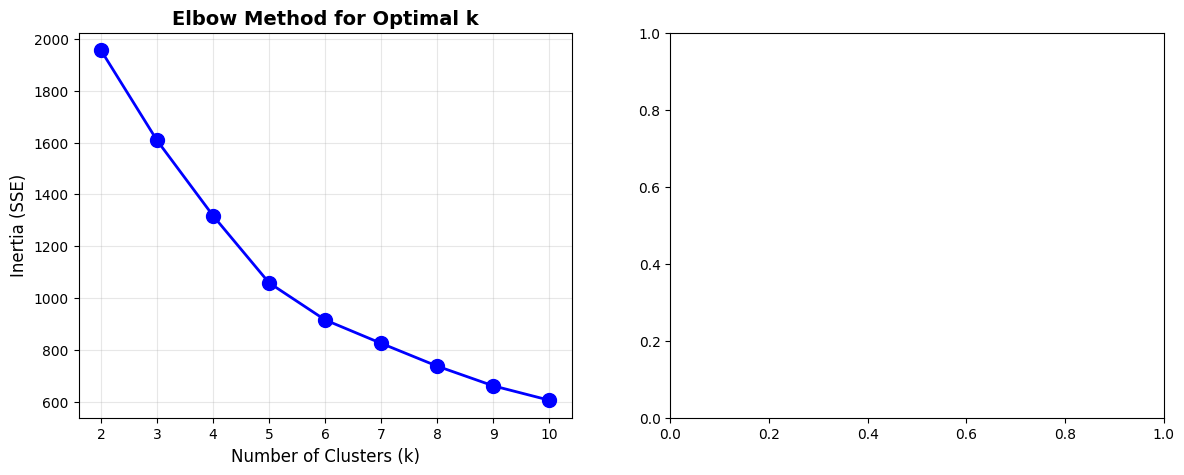

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, inertias, 'bo-', markersize=10, linewidth=2)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (SSE)', fontsize=12)
axes[0].set_title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(list(k_range))

In [20]:
axes[1].plot(k_range, silhouette_scores, 'ro-', markersize=10, linewidth=2)
best_k = k_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
axes[1].annotate(f'Best k={best_k}\nScore={best_score:.3f}', 
                xy=(best_k, best_score), xytext=(best_k+1.5, best_score+0.02),
                arrowprops=dict(arrowstyle='->', color='red'),
                fontsize=11, fontweight='bold', color='red')
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score vs Number of Clusters', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.savefig('kmeans_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nEvaluation Results:")
for k, sil in zip(k_range, silhouette_scores):
    marker = " <-- BEST" if k == best_k else ""
    print(f"  k={k}: Silhouette={sil:.3f}{marker}")


<Figure size 640x480 with 0 Axes>


Evaluation Results:
  k=2: Silhouette=0.547
  k=3: Silhouette=0.548 <-- BEST
  k=4: Silhouette=0.348
  k=5: Silhouette=0.369
  k=6: Silhouette=0.378
  k=7: Silhouette=0.334
  k=8: Silhouette=0.320
  k=9: Silhouette=0.309
  k=10: Silhouette=0.311


In [21]:
print("\n" + "="*60)
print("Optimal K Selection")
print("="*60)
print(f"- Selected k: {best_k} (highest silhouette score: {best_score:.3f})")
print(f"- Elbow method: Look for bend in left plot (usually k=3 or k=4)")
print(f"- Final choice: k={best_k} based on quantitative metric")


Optimal K Selection
- Selected k: 3 (highest silhouette score: 0.548)
- Elbow method: Look for bend in left plot (usually k=3 or k=4)
- Final choice: k=3 based on quantitative metric


Compare Clustering Performance: Raw vs PCA-Reduced Data

In [22]:
optimal_k = best_k

kmeans_raw = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_raw = kmeans_raw.fit_predict(features_scaled)
silhouette_raw = silhouette_score(features_scaled, labels_raw)

kmeans_pca = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(features_pca)
silhouette_pca = silhouette_score(features_pca, labels_pca)

comparison_results = pd.DataFrame({
    'Dataset': ['Raw Scaled (6D)', f'PCA-Reduced ({n_components_pca}D)'],
    'Silhouette Score': [silhouette_raw, silhouette_pca],
    'Inertia': [kmeans_raw.inertia_, kmeans_pca.inertia_]
})

print("\nClustering Performance Comparison:")
print(comparison_results.to_string(index=False))


Clustering Performance Comparison:
         Dataset  Silhouette Score     Inertia
 Raw Scaled (6D)          0.548287 1608.431149
PCA-Reduced (4D)          0.357350 1467.858714


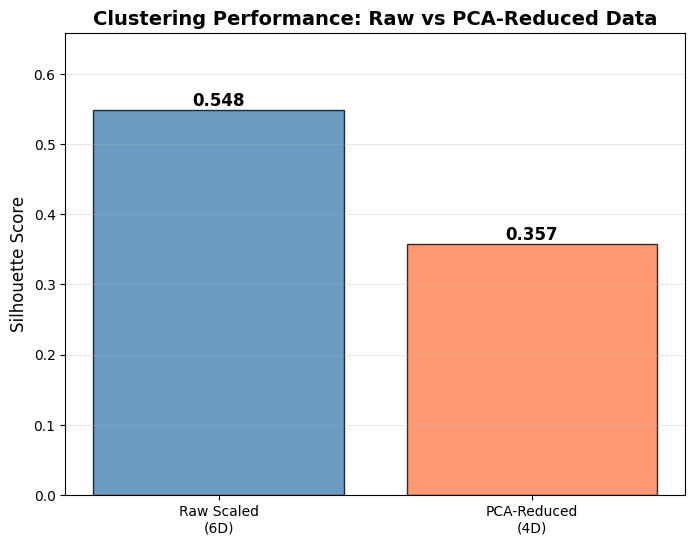

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
x_pos = [0, 1]
bars = ax.bar(x_pos, [silhouette_raw, silhouette_pca], 
              color=['steelblue', 'coral'], alpha=0.8, edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(['Raw Scaled\n(6D)', f'PCA-Reduced\n({n_components_pca}D)'])
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Clustering Performance: Raw vs PCA-Reduced Data', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(silhouette_raw, silhouette_pca) * 1.2)

for bar, score in zip(bars, [silhouette_raw, silhouette_pca]):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.grid(True, alpha=0.3, axis='y')
plt.savefig('raw_vs_pca_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
if silhouette_pca > silhouette_raw:
    final_labels = labels_pca
    final_method = "PCA-Reduced"
    improvement = silhouette_pca - silhouette_raw
else:
    final_labels = labels_raw
    final_method = "Raw Scaled"
    improvement = silhouette_raw - silhouette_pca

In [25]:
print("\n" + "="*60)
print("Raw vs PCA-Reduced Data")
print("="*60)
print(f"- Better performing: {final_method}")
print(f"- Difference: {improvement:.3f} silhouette points")
print(f"- Interpretation:")
if silhouette_pca > silhouette_raw:
    print(f"  - PCA removed noise and redundancy")
    print(f"  - Cleaner cluster boundaries in reduced dimensions")
    print(f"  - Trade-off: Some fine-grained detail lost, but better separation")
else:
    print(f"  - Raw data preserved subtle spending patterns")
    print(f"  - All 6 product categories contribute meaningfully")
    print(f"  - Trade-off: Higher dimensionality, but more accurate clusters")

print(f"\n• Using {final_method} for final analysis")



Raw vs PCA-Reduced Data
- Better performing: Raw Scaled
- Difference: 0.191 silhouette points
- Interpretation:
  - Raw data preserved subtle spending patterns
  - All 6 product categories contribute meaningfully
  - Trade-off: Higher dimensionality, but more accurate clusters

• Using Raw Scaled for final analysis


Cluster Visualization

In [26]:
pca_2d = PCA(n_components=2)
features_pca_2d = pca_2d.fit_transform(features_scaled)

kmeans_2d = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters_2d = kmeans_2d.fit_predict(features_pca_2d)

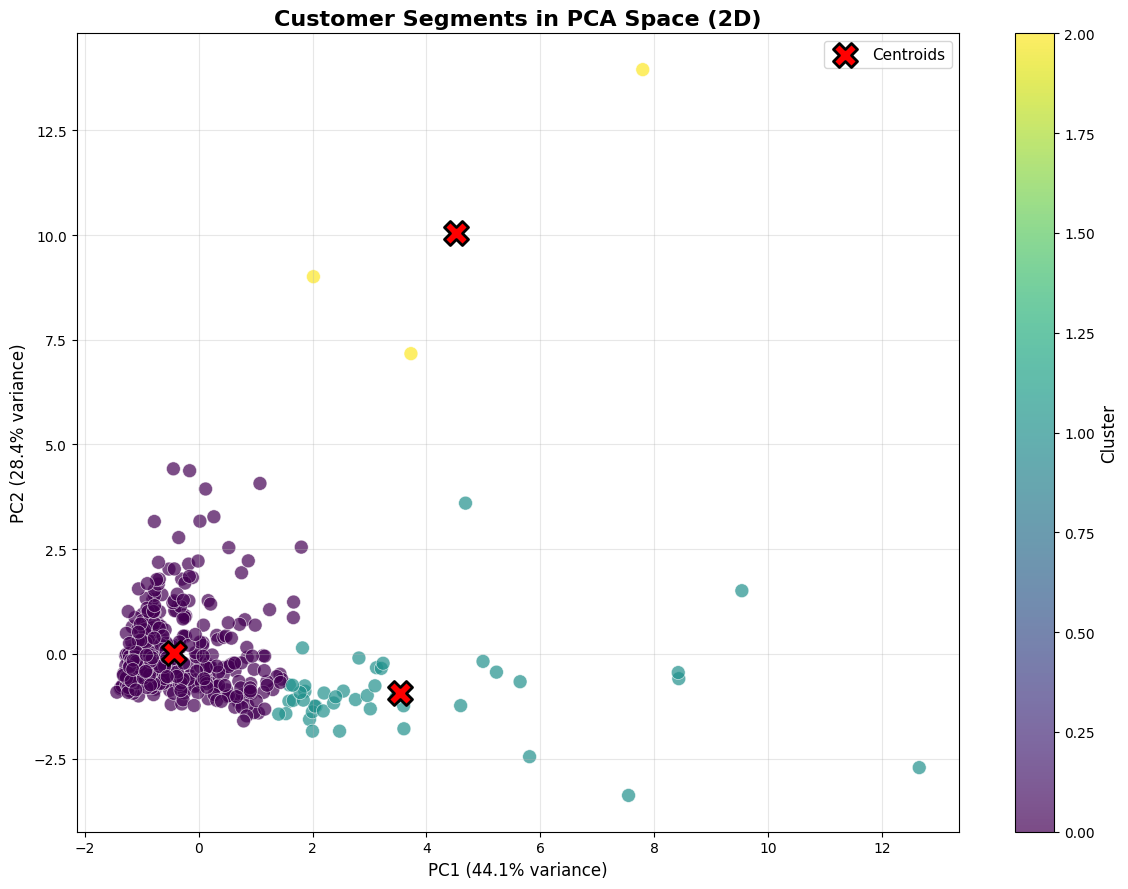

2D visualization captures 72.5% of total variance


In [27]:
fig, ax = plt.subplots(figsize=(12, 9))

scatter = ax.scatter(features_pca_2d[:, 0], features_pca_2d[:, 1],
                    c=clusters_2d, cmap='viridis', 
                    s=100, alpha=0.7, edgecolors='w', linewidth=0.5)

centroids = kmeans_2d.cluster_centers_
ax.scatter(centroids[:, 0], centroids[:, 1],
          c='red', marker='X', s=300, edgecolors='black', linewidth=2,
          label='Centroids', zorder=5)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('Customer Segments in PCA Space (2D)', fontsize=16, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Cluster', fontsize=12)

plt.tight_layout()
plt.savefig('cluster_visualization_2d.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"2D visualization captures {sum(pca_2d.explained_variance_ratio_):.1%} of total variance")

In [28]:
print("\n" + "="*60)
print("Cluster Visualization")
print("="*60)
print(f"• {optimal_k} distinct segments visible in 2D PCA space")
print(f"• PC1: {pca_2d.explained_variance_ratio_[0]:.1%} of variance")
print(f"• PC2: {pca_2d.explained_variance_ratio_[1]:.1%} of variance")


Cluster Visualization
• 3 distinct segments visible in 2D PCA space
• PC1: 44.1% of variance
• PC2: 28.4% of variance


PRINCIPAL COMPONENT INTERPRETATION

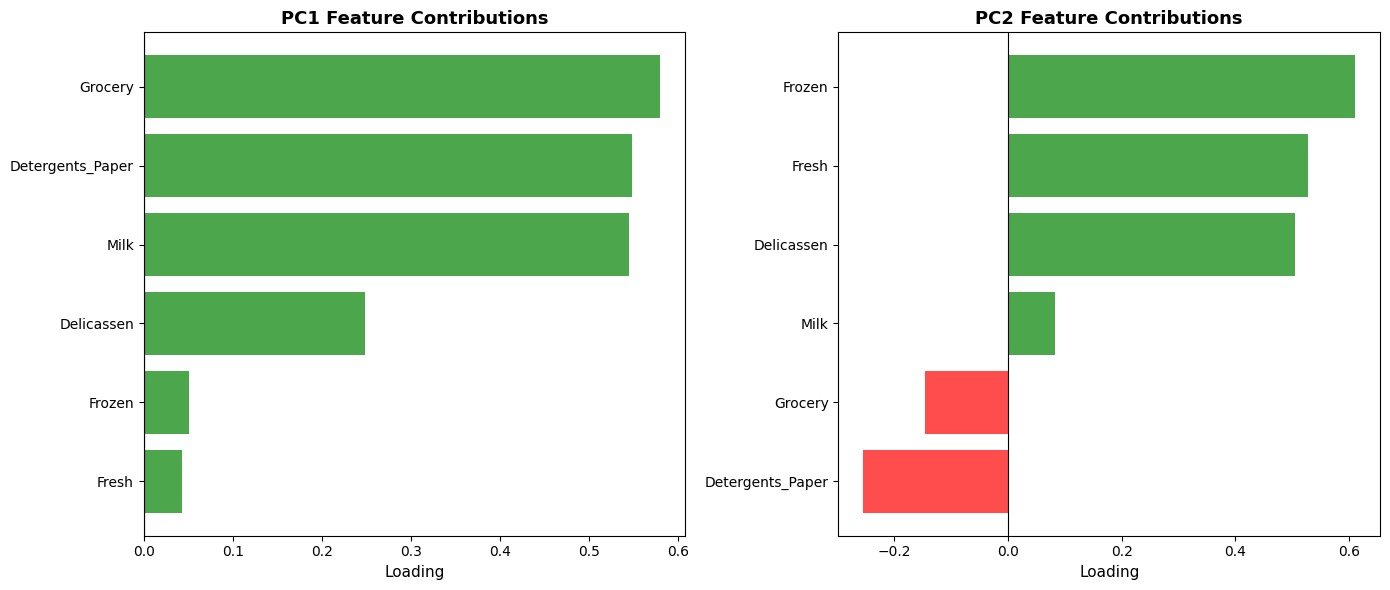


PC1 Loadings (top contributors):
Grocery             0.579256
Detergents_Paper    0.548640
Milk                0.545118
Delicassen          0.248682
Frozen              0.051189
Fresh               0.042884
dtype: float64

PC2 Loadings (top contributors):
Frozen              0.611278
Fresh               0.527932
Delicassen          0.504207
Detergents_Paper    0.255233
Grocery             0.146088
Milk                0.083168
dtype: float64


In [29]:
feature_names = features.columns
pc1_loadings = pd.Series(pca_2d.components_[0], index=feature_names)
pc2_loadings = pd.Series(pca_2d.components_[1], index=feature_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pc1_sorted = pc1_loadings.sort_values()
colors = ['red' if x < 0 else 'green' for x in pc1_sorted]
axes[0].barh(range(len(pc1_sorted)), pc1_sorted.values, color=colors, alpha=0.7)
axes[0].set_yticks(range(len(pc1_sorted)))
axes[0].set_yticklabels(pc1_sorted.index)
axes[0].set_xlabel('Loading', fontsize=11)
axes[0].set_title('PC1 Feature Contributions', fontsize=13, fontweight='bold')
axes[0].axvline(x=0, color='black', linewidth=0.8)

pc2_sorted = pc2_loadings.sort_values()
colors = ['red' if x < 0 else 'green' for x in pc2_sorted]
axes[1].barh(range(len(pc2_sorted)), pc2_sorted.values, color=colors, alpha=0.7)
axes[1].set_yticks(range(len(pc2_sorted)))
axes[1].set_yticklabels(pc2_sorted.index)
axes[1].set_xlabel('Loading', fontsize=11)
axes[1].set_title('PC2 Feature Contributions', fontsize=13, fontweight='bold')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('pca_component_loadings.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nPC1 Loadings (top contributors):")
print(pc1_loadings.abs().sort_values(ascending=False))

print("\nPC2 Loadings (top contributors):")
print(pc2_loadings.abs().sort_values(ascending=False))

In [30]:
print("\n" + "="*60)
print("INTERPRETATION:")
print("="*60)

top_pc1 = pc1_loadings.abs().nlargest(2).index.tolist()
if pc1_loadings.std() < 0.3:
    pc1_meaning = "Overall Spending Volume (all categories similar)"
else:
    pc1_meaning = f"Contrast between {top_pc1[0]} and {top_pc1[1]}"

 
top_pc2 = pc2_loadings.abs().nlargest(2).index.tolist()
if 'Fresh' in top_pc2 and 'Frozen' in top_pc2:
    pc2_meaning = "Fresh vs Frozen/Detergents (Perishable vs Shelf-Stable)"
elif 'Milk' in top_pc2 and 'Grocery' in top_pc2:
    pc2_meaning = "Dairy-Heavy vs Grocery-Heavy"
else:
    pc2_meaning = f"Contrast between {top_pc2[0]} and {top_pc2[1]}"

print(f"\nPC1: {pc1_meaning}")
print(f"  Key drivers: {', '.join(top_pc1)}")
print(f"\nPC2: {pc2_meaning}")
print(f"  Key drivers: {', '.join(top_pc2)}")



INTERPRETATION:

PC1: Overall Spending Volume (all categories similar)
  Key drivers: Grocery, Detergents_Paper

PC2: Fresh vs Frozen/Detergents (Perishable vs Shelf-Stable)
  Key drivers: Frozen, Fresh


In [31]:
print("\n" + "="*60)
print("Principal Component Interpretation")
print("="*60)
print(f"• PC1 represents: {pc1_meaning}")
print(f"• PC2 represents: {pc2_meaning}")
print(f"• Business insight: Segments separate by spending volume (PC1) and product mix (PC2)")


Principal Component Interpretation
• PC1 represents: Overall Spending Volume (all categories similar)
• PC2 represents: Fresh vs Frozen/Detergents (Perishable vs Shelf-Stable)
• Business insight: Segments separate by spending volume (PC1) and product mix (PC2)


Cluster Insights

In [32]:
analysis_df = features.copy()
analysis_df['Cluster'] = final_labels
analysis_df['Channel'] = identifiers['Channel']

cluster_profiles = analysis_df.groupby('Cluster')[features.columns].mean()
cluster_sizes = analysis_df['Cluster'].value_counts().sort_index()

print("\nCluster Sizes:")
for cid in sorted(cluster_sizes.index):
    pct = cluster_sizes[cid] / len(analysis_df) * 100
    print(f"  Cluster {cid}: {cluster_sizes[cid]} customers ({pct:.1f}%)")

print("\nCluster Profiles (Mean Annual Spending):")
print(cluster_profiles.round(0))


Cluster Sizes:
  Cluster 0: 45 customers (10.2%)
  Cluster 1: 393 customers (89.3%)
  Cluster 2: 2 customers (0.5%)

Cluster Profiles (Mean Annual Spending):
           Fresh     Milk  Grocery   Frozen  Detergents_Paper  Delicassen
Cluster                                                                  
0        10441.0  19386.0  28656.0   2190.0           13328.0      2374.0
1        12063.0   4115.0   5535.0   2941.0            1696.0      1299.0
2        34782.0  30367.0  16898.0  48702.0             756.0     26776.0


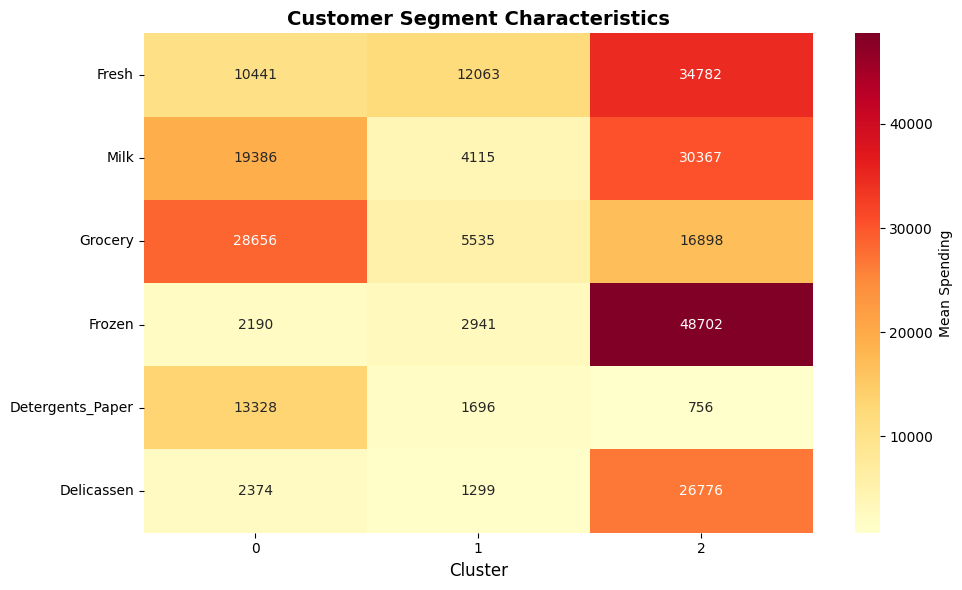

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(cluster_profiles.T, annot=True, fmt='.0f', cmap='YlOrRd', 
            cbar_kws={'label': 'Mean Spending'}, ax=ax)
ax.set_title('Customer Segment Characteristics', fontsize=14, fontweight='bold')
ax.set_xlabel('Cluster', fontsize=12)
plt.tight_layout()
plt.savefig('cluster_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [34]:
channel_dist = pd.crosstab(analysis_df['Cluster'], analysis_df['Channel'], normalize='index') * 100
print("\nChannel Distribution by Cluster (%):")
print(channel_dist.round(1))
print("  (1 = Horeca/Restaurant/Cafe, 2 = Retail)")


Channel Distribution by Cluster (%):
Channel      1     2
Cluster             
0          2.2  97.8
1         75.1  24.9
2        100.0   0.0
  (1 = Horeca/Restaurant/Cafe, 2 = Retail)


In [36]:
print("\n" + "="*60)
print("CLUSTER-BY-CLUSTER ANALYSIS:")
print("="*60)

for cluster_id in sorted(analysis_df['Cluster'].unique()):
    cluster_data = analysis_df[analysis_df['Cluster'] == cluster_id]
    other_data = analysis_df[analysis_df['Cluster'] != cluster_id]
    
    print(f"\n--- CLUSTER {cluster_id} ({len(cluster_data)} customers) ---")

    differences = {}
    for col in features.columns:
        c_mean = cluster_data[col].mean()
        o_mean = other_data[col].mean()
        if o_mean > 0:
            pct_diff = ((c_mean - o_mean) / o_mean) * 100
            differences[col] = pct_diff
    
    top_3 = sorted(differences.items(), key=lambda x: abs(x[1]), reverse=True)[:3]
    
    print("  Key characteristics:")
    for feature, diff in top_3:
        level = "HIGH" if diff > 0 else "LOW"
        print(f"    - {feature}: {level} ({diff:+.0f}% vs others)")

    horeca_pct = (cluster_data['Channel'] == 1).mean() * 100
    print(f"  Customer type: {horeca_pct:.0f}% Horeca, {100-horeca_pct:.0f}% Retail")


CLUSTER-BY-CLUSTER ANALYSIS:

--- CLUSTER 0 (45 customers) ---
  Key characteristics:
    - Detergents_Paper: HIGH (+688% vs others)
    - Grocery: HIGH (+412% vs others)
    - Milk: HIGH (+356% vs others)
  Customer type: 2% Horeca, 98% Retail

--- CLUSTER 1 (393 customers) ---
  Key characteristics:
    - Detergents_Paper: LOW (-87% vs others)
    - Grocery: LOW (-80% vs others)
    - Milk: LOW (-79% vs others)
  Customer type: 75% Horeca, 25% Retail

--- CLUSTER 2 (2 customers) ---
  Key characteristics:
    - Delicassen: HIGH (+1800% vs others)
    - Frozen: HIGH (+1601% vs others)
    - Milk: HIGH (+434% vs others)
  Customer type: 100% Horeca, 0% Retail


In [37]:
print("\n" + "="*60)
print("BUSINESS STRATEGY RECOMMENDATIONS:")
print("="*60)

for cluster_id in sorted(cluster_profiles.index):
    profile = cluster_profiles.loc[cluster_id]
    total_spend = profile.sum()
    avg_spend = cluster_profiles.sum(axis=1).mean()
    
    if total_spend > avg_spend * 1.2:
        spend_level = "High-Value"
        strategy = "Premium service, loyalty programs, cross-selling"
    elif total_spend < avg_spend * 0.8:
        spend_level = "Budget-Conscious"
        strategy = "Volume discounts, promotional offers, cost-effective products"
    else:
        spend_level = "Mid-Tier"
        strategy = "Targeted upselling, category expansion"
    
    top_product = profile.idxmax()
    if top_product in ['Fresh', 'Milk']:
        product_focus = "Perishables/Fresh-focused"
    elif top_product in ['Grocery', 'Detergents_Paper']:
        product_focus = "Staples/Retail-focused"
    else:
        product_focus = "Frozen/Delicatessen-focused"
    
    print(f"\nCluster {cluster_id}: {spend_level} {product_focus}")
    print(f"  - Strategy: {strategy}")

    if profile['Fresh'] > cluster_profiles['Fresh'].mean():
        print(f"     - Emphasize fresh/organic product lines")
    if profile['Frozen'] > cluster_profiles['Frozen'].mean():
        print(f"     - Offer frozen bulk discounts")
    if profile['Detergents_Paper'] > cluster_profiles['Detergents_Paper'].mean():
        print(f"     - Bundle with household essentials")


BUSINESS STRATEGY RECOMMENDATIONS:

Cluster 0: Mid-Tier Staples/Retail-focused
  - Strategy: Targeted upselling, category expansion
     - Bundle with household essentials

Cluster 1: Budget-Conscious Perishables/Fresh-focused
  - Strategy: Volume discounts, promotional offers, cost-effective products

Cluster 2: High-Value Frozen/Delicatessen-focused
  - Strategy: Premium service, loyalty programs, cross-selling
     - Emphasize fresh/organic product lines
     - Offer frozen bulk discounts


In [38]:
print("\n" + "="*60)
print("Cluster Insights Summary")
print("="*60)
print(f"- Identified {optimal_k} distinct customer segments:")
print(f"  - Differentiated by total spending volume and product category focus")
print(f"  - Channel alignment varies (Horeca vs Retail concentration)")
print(f"- Strategic implications:")
print(f"  - Tailored marketing campaigns per segment")
print(f"  - Inventory optimization based on cluster preferences")
print(f"  - Pricing strategies aligned to spending behavior")


Cluster Insights Summary
- Identified 3 distinct customer segments:
  - Differentiated by total spending volume and product category focus
  - Channel alignment varies (Horeca vs Retail concentration)
- Strategic implications:
  - Tailored marketing campaigns per segment
  - Inventory optimization based on cluster preferences
  - Pricing strategies aligned to spending behavior


Final Summary

In [39]:
print("\n" + "="*70)
print("ASSIGNMENT COMPLETE - ALL DELIVERABLES")
print("="*70)
print(f"""
- Deliverable 1: Cleaned dataset (440 records, 6 features, Channel separated)
- Deliverable 2: PCA analysis (4 components, {sum(explained_var[:4]):.1%} variance)
- Deliverable 3: K-Means (k={optimal_k} selected, silhouette={best_score:.3f})
- Deliverable 4: Raw vs PCA comparison ({final_method} performed better)
- Deliverable 5: 2D cluster visualization (PC1 vs PC2)
- Deliverable 6: PC1/PC2 interpretation provided
- Deliverable 7: Business insights and strategies for each segment
""")


ASSIGNMENT COMPLETE - ALL DELIVERABLES

- Deliverable 1: Cleaned dataset (440 records, 6 features, Channel separated)
- Deliverable 2: PCA analysis (4 components, 94.2% variance)
- Deliverable 3: K-Means (k=3 selected, silhouette=0.548)
- Deliverable 4: Raw vs PCA comparison (Raw Scaled performed better)
- Deliverable 5: 2D cluster visualization (PC1 vs PC2)
- Deliverable 6: PC1/PC2 interpretation provided
- Deliverable 7: Business insights and strategies for each segment

